In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

## Leitura da Base Dados

In [36]:
df = pd.read_json('/content/curingas_balatro.json')

In [37]:
df.head()

,Nome,Raridade,Requisito de Desbloqueio,Efeito,Preço Base
0,Joker,Comum,Disponível desde o início,+4 Mult,2
1,Coringa ganancioso,Comum,Disponível desde o início,Cartas jogadas com naipe de Diamante dão +4 Mu...,5
2,Coringa Lusty,Comum,Disponível desde o início,Cartas jogadas com naipe de Coração dão +4 Mul...,5
3,Coringa Colérico,Comum,Disponível desde o início,Cartas jogadas com naipe de Espadas dão +4 Mul...,5
4,Coringa Glutão,Comum,Disponível desde o início,Cartas jogadas com naipe de Clube dão +4 Mult ...,5


## EDA (Análise Exploratória dos Dados)

In [48]:
# Função para análise exploratória
def analise_exploratoria(df):
    print("=== INFORMAÇÕES BÁSICAS DO DATASET ===")
    print(f"Número de curingas: {len(df)}")
    print("\n=== PRIMEIROS REGISTROS ===")
    print(df.head())

    print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
    print(df.describe(include='all'))

    print("\n=== DISTRIBUIÇÃO POR RARIDADE ===")
    print(df['Raridade'].value_counts())

    print("\n=== DISTRIBUIÇÃO POR REQUISITO DE DESBLOQUEIO ===")
    print(df['Requisito de Desbloqueio'].value_counts())

    # Visualizações
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='Raridade')
    plt.title('Distribuição de Curingas por Raridade')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Preço base por raridade
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Raridade', y='Preço Base')
    plt.title('Distribuição de Preço Base por Raridade')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Verificar correlações
    if 'Preço Base' in df.columns:
        print("\n=== ANÁLISE DE CORRELAÇÃO ===")
        df_encoded = df.copy()

        try:
            df_encoded['Preço Base'] = pd.to_numeric(df_encoded['Preço Base'], errors='coerce')

            # Codificar Raridade
            raridade_map = {'Comum': 1, 'Incomum': 2, 'Raro': 3, 'Lendário': 4}
            if 'Raridade' in df.columns:
                df_encoded['Raridade_Code'] = df['Raridade'].map(raridade_map)

            num_cols = df_encoded.select_dtypes(include=[np.number]).columns

            if len(num_cols) > 1:
                if not df_encoded[num_cols].isna().any().any():
                    corr = df_encoded[num_cols].corr()
                    plt.figure(figsize=(10, 8))
                    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
                    plt.title('Matriz de Correlação')
                    plt.tight_layout()
                    plt.show()
                else:
                    print("Aviso: Valores ausentes detectados após conversão numérica. Pulando análise de correlação.")
            else:
                print("Aviso: Menos de duas colunas numéricas disponíveis para análise de correlação.")
        except Exception as e:
            print(f"Erro na análise de correlação: {e}")
            print("Pulando análise de correlação.")

## Levantamento dos possíveis testes de Hipóteses a serem feitos

In [49]:
# Formulação e testes de hipóteses
def testes_hipoteses(df):
    print("\n=== TESTES DE HIPÓTESES ===")

    # 1. Hipótese: Curingas de maior raridade têm preço base maior
    print("\n1. Hipótese: Curingas de maior raridade têm preço base significativamente maior")

    if 'Raridade' in df.columns and 'Preço Base' in df.columns:
        df_temp = df.copy()
        try:
            df_temp['Preço Base'] = pd.to_numeric(df_temp['Preço Base'], errors='coerce')

            grupos_raridade = {}
            for raridade in df_temp['Raridade'].unique():
                preco_grupo = df_temp[df_temp['Raridade'] == raridade]['Preço Base'].dropna()
                if len(preco_grupo) > 0:  # Adicionar apenas se houver dados válidos
                    grupos_raridade[raridade] = preco_grupo

            if len(grupos_raridade) > 1 and all(len(grupo) > 0 for grupo in grupos_raridade.values()):
                raridades = list(grupos_raridade.keys())
                precos_por_raridade = list(grupos_raridade.values())

                try:
                    f_stat, p_valor = stats.f_oneway(*precos_por_raridade)

                    print(f"ANOVA: F-statistic = {f_stat:.4f}, p-value = {p_valor:.4f}")
                    if p_valor < 0.05:
                        print("Conclusão: Rejeitamos a hipótese nula. Há diferença significativa nos preços entre as diferentes raridades.")
                        try:
                            from statsmodels.stats.multicomp import pairwise_tukeyhsd

                            todas_precos = np.concatenate(precos_por_raridade)
                            grupos_labels = np.concatenate([[r] * len(precos_por_raridade[i]) for i, r in enumerate(raridades)])

                            tukey = pairwise_tukeyhsd(endog=todas_precos, groups=grupos_labels, alpha=0.05)
                            print("\nResultados do teste post-hoc de Tukey:")
                            print(tukey)
                        except Exception as e:
                            print(f"Não foi possível realizar o teste de Tukey: {e}")
                    else:
                        print("Conclusão: Não há evidência suficiente para rejeitar a hipótese nula. Não detectamos diferença significativa nos preços entre as raridades.")
                except Exception as e:
                    print(f"Erro ao realizar ANOVA: {e}")
                    print("Verificando os dados dos grupos:")
                    for raridade, grupo in grupos_raridade.items():
                        print(f"Raridade '{raridade}': {grupo.describe()}")
            else:
                print("Não há grupos suficientes com dados válidos para realizar ANOVA.")
        except Exception as e:
            print(f"Erro ao processar dados para a hipótese 1: {e}")
    else:
        print("Colunas necessárias não encontradas no dataset.")

    # 2. Hipótese: Existe correlação entre o requisito de desbloqueio e o preço base
    print("\n2. Hipótese: Existe correlação entre o requisito de desbloqueio e o preço base")

    if 'Requisito de Desbloqueio' in df.columns and 'Preço Base' in df.columns:
        df_temp = df.copy()
        try:
            df_temp['Preço Base'] = pd.to_numeric(df_temp['Preço Base'], errors='coerce')

            try:
                req_stats = df_temp.groupby('Requisito de Desbloqueio')['Preço Base'].agg(['mean', 'median', 'std']).reset_index()
                print("Estatísticas de preço por requisito de desbloqueio:")
                print(req_stats)
            except Exception as e:
                print(f"Erro ao calcular estatísticas: {e}")

            grupos_requisito = {}
            for req in df_temp['Requisito de Desbloqueio'].unique():
                preco_grupo = df_temp[df_temp['Requisito de Desbloqueio'] == req]['Preço Base'].dropna()
                if len(preco_grupo) > 0:
                    grupos_requisito[req] = preco_grupo

            if len(grupos_requisito) > 1 and all(len(grupo) > 0 for grupo in grupos_requisito.values()):
                try:
                    precos_por_requisito = list(grupos_requisito.values())
                    f_stat, p_valor = stats.f_oneway(*precos_por_requisito)

                    print(f"ANOVA: F-statistic = {f_stat:.4f}, p-value = {p_valor:.4f}")
                    if p_valor < 0.05:
                        print("Conclusão: Rejeitamos a hipótese nula. Há uma relação significativa entre o requisito de desbloqueio e o preço base.")
                    else:
                        print("Conclusão: Não há evidência suficiente para rejeitar a hipótese nula. Não detectamos relação significativa entre o requisito de desbloqueio e o preço base.")
                except Exception as e:
                    print(f"Erro ao realizar ANOVA: {e}")
            else:
                print("Não há grupos suficientes com dados válidos para realizar ANOVA.")
        except Exception as e:
            print(f"Erro ao processar dados para a hipótese 2: {e}")
    else:
        print("Colunas necessárias não encontradas no dataset.")

    # 3. Hipótese: A distribuição de curingas entre as raridades é uniforme
    print("\n3. Hipótese: A distribuição de curingas entre as raridades é uniforme")

    if 'Raridade' in df.columns:
        try:
            counts = df['Raridade'].value_counts()
            print("Contagem por raridade:")
            print(counts)

            # Teste Chi-quadrado
            if len(counts) > 1:
                observed = counts.values
                n_categories = len(counts)
                expected = np.ones(n_categories) * (len(df) / n_categories)

                if all(observed >= 5) and all(expected >= 5):
                    chi2, p_valor = stats.chisquare(observed, expected)

                    print(f"Chi-quadrado: estatística = {chi2:.4f}, p-value = {p_valor:.4f}")
                    if p_valor < 0.05:
                        print("Conclusão: Rejeitamos a hipótese nula. A distribuição de curingas entre as raridades não é uniforme.")
                    else:
                        print("Conclusão: Não há evidência suficiente para rejeitar a hipótese nula. A distribuição parece ser uniforme.")
                else:
                    print("Aviso: Algumas categorias têm menos de 5 observações, o que pode afetar a validade do teste Chi-quadrado.")
                    chi2, p_valor = stats.chisquare(observed, expected)
                    print(f"Chi-quadrado (com ressalvas): estatística = {chi2:.4f}, p-value = {p_valor:.4f}")
            else:
                print("Não há categorias suficientes para realizar o teste Chi-quadrado.")
        except Exception as e:
            print(f"Erro ao realizar teste Chi-quadrado: {e}")
    else:
        print("Coluna 'Raridade' não encontrada no dataset.")

## Análise de clusterização dos Curingas

In [50]:
# Análise adicional: Clustering de curingas com base no preço e raridade
def analise_clustering(df):
    print("\n=== ANÁLISE DE CLUSTERING ===")

    if 'Preço Base' in df.columns and 'Raridade' in df.columns:
        try:
            df_cluster = df.copy()

            df_cluster['Preço Base'] = pd.to_numeric(df_cluster['Preço Base'], errors='coerce')

            df_cluster = df_cluster.dropna(subset=['Preço Base', 'Raridade'])

            if len(df_cluster) < 3:
                print("Não há dados suficientes para realizar a análise de clustering após remover valores ausentes.")
                return

            raridade_map = {'Comum': 1, 'Incomum': 2, 'Raro': 3, 'Lendário': 4}
            df_cluster['Raridade_Num'] = df_cluster['Raridade'].map(raridade_map)

            df_cluster = df_cluster.dropna(subset=['Raridade_Num'])

            if len(df_cluster) < 3:
                print("Não há dados suficientes para realizar a análise de clustering após mapear a raridade.")
                return

            X = df_cluster[['Preço Base', 'Raridade_Num']].values

            from sklearn.preprocessing import StandardScaler
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            from sklearn.cluster import KMeans

            inertia = []
            max_clusters = min(10, len(df_cluster))
            for k in range(1, max_clusters + 1):
                kmeans = KMeans(n_clusters=k, random_state=42)
                kmeans.fit(X_scaled)
                inertia.append(kmeans.inertia_)

            plt.figure(figsize=(10, 6))
            plt.plot(range(1, max_clusters + 1), inertia, marker='o')
            plt.title('Método do Cotovelo para Determinar o Número Ideal de Clusters')
            plt.xlabel('Número de Clusters')
            plt.ylabel('Inércia')
            plt.grid(True)
            plt.show()

            n_clusters = min(4, len(df_cluster))
            if n_clusters < 2:
                n_clusters = 2

            kmeans = KMeans(n_clusters=n_clusters, random_state=42)
            df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

            plt.figure(figsize=(12, 8))
            scatter = plt.scatter(df_cluster['Preço Base'], df_cluster['Raridade_Num'],
                                c=df_cluster['Cluster'], cmap='viridis',
                                s=100, alpha=0.8)

            for i, txt in enumerate(df_cluster['Nome']):
                plt.annotate(txt, (df_cluster['Preço Base'].iloc[i], df_cluster['Raridade_Num'].iloc[i]),
                            fontsize=9, alpha=0.7)

            plt.colorbar(scatter, label='Cluster')
            plt.xlabel('Preço Base')
            plt.ylabel('Raridade (1=Comum, 2=Incomum, 3=Raro, 4=Lendário)')
            plt.title('Clusters de Curingas com base no Preço e Raridade')
            plt.grid(True, alpha=0.3)
            plt.show()

            print("\nEstatísticas por cluster:")
            for cluster in range(n_clusters):
                cluster_data = df_cluster[df_cluster['Cluster'] == cluster]
                print(f"\nCluster {cluster} ({len(cluster_data)} curingas):")
                print(f"Preço Base Médio: {cluster_data['Preço Base'].mean():.2f}")
                print("Distribuição de Raridade:")
                print(cluster_data['Raridade'].value_counts())
                print("Nomes dos Curingas neste cluster:")
                print(", ".join(cluster_data['Nome'].values))
        except Exception as e:
            print(f"Erro na análise de clustering: {e}")
            print("Detalhes sobre o dataframe:")
            print(f"Número de linhas: {len(df)}")
            print(f"Colunas disponíveis: {df.columns.tolist()}")
            if 'Preço Base' in df.columns:
                print(f"Tipo de dados da coluna 'Preço Base': {df['Preço Base'].dtype}")
                print(f"Primeiros valores da coluna 'Preço Base': {df['Preço Base'].head()}")
    else:
        print("Colunas necessárias não encontradas no dataset.")

## Resultados: Análise Estatísticas dos Curingas de Balatro

### Resultados Análise Exploratória

=== INFORMAÇÕES BÁSICAS DO DATASET ===
Número de curingas: 150

=== PRIMEIROS REGISTROS ===
                 Nome Raridade   Requisito de Desbloqueio  \
0               Joker    Comum  Disponível desde o início   
1  Coringa ganancioso    Comum  Disponível desde o início   
2       Coringa Lusty    Comum  Disponível desde o início   
3    Coringa Colérico    Comum  Disponível desde o início   
4      Coringa Glutão    Comum  Disponível desde o início   

                                              Efeito  Preço Base  
0                                            +4 Mult           2  
1  Cartas jogadas com naipe de Diamante dão +4 Mu...           5  
2  Cartas jogadas com naipe de Coração dão +4 Mul...           5  
3  Cartas jogadas com naipe de Espadas dão +4 Mul...           5  
4  Cartas jogadas com naipe de Clube dão +4 Mult ...           5  

=== ESTATÍSTICAS DESCRITIVAS ===
                  Nome Raridade   Requisito de Desbloqueio   Efeito  \
count              150      150   

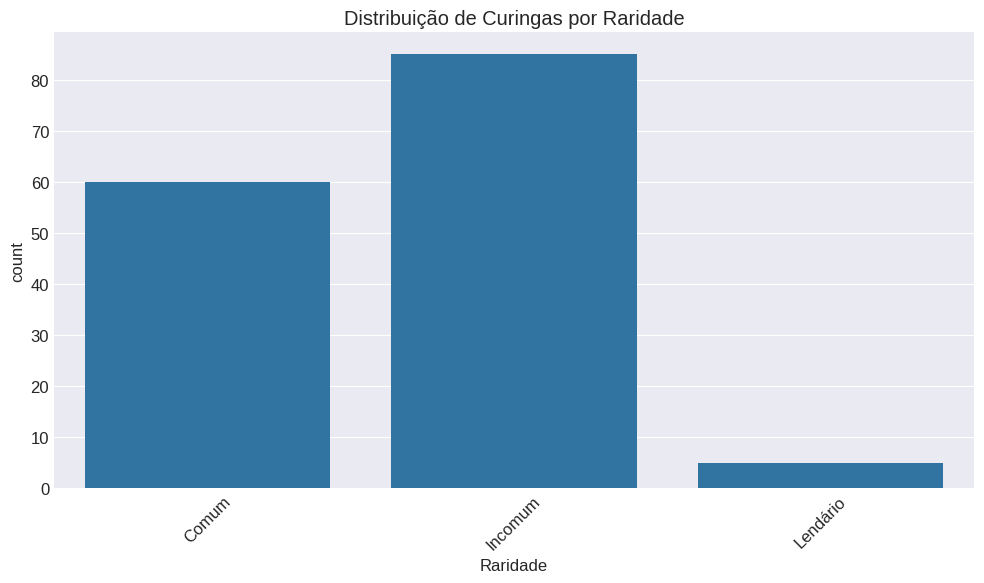

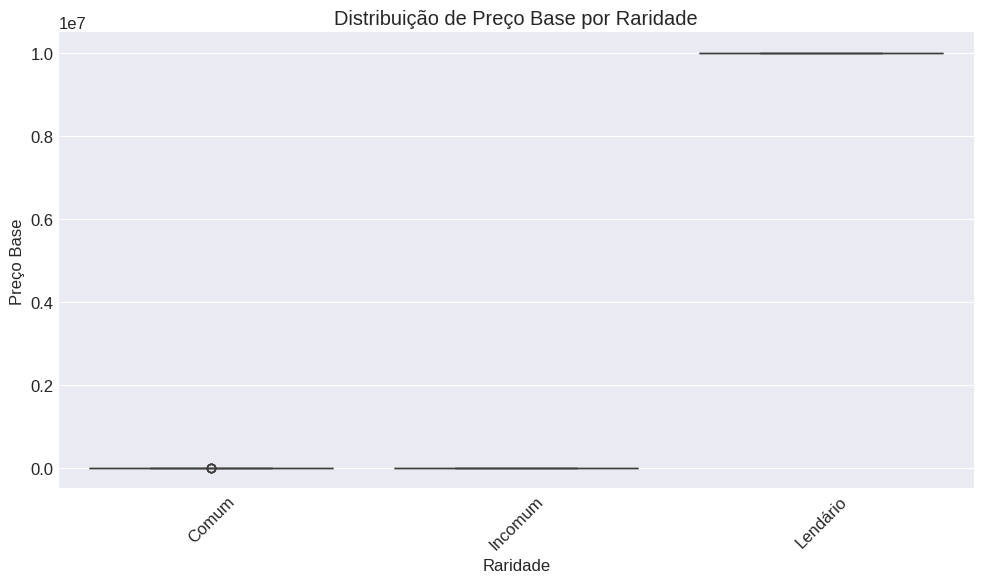


=== ANÁLISE DE CORRELAÇÃO ===


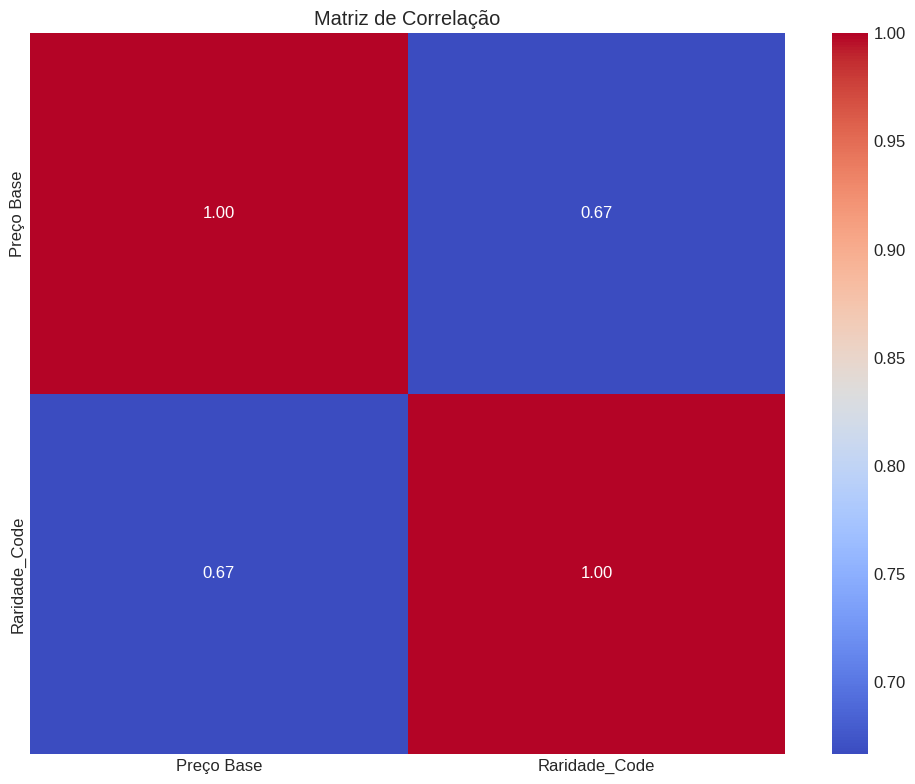

In [51]:
analise_exploratoria(df)

### Resultados Análise de Teste de Hipóteses

In [52]:
testes_hipoteses(df)


=== TESTES DE HIPÓTESES ===

1. Hipótese: Curingas de maior raridade têm preço base significativamente maior
ANOVA: F-statistic = 37384859727450.4766, p-value = 0.0000
Conclusão: Rejeitamos a hipótese nula. Há diferença significativa nos preços entre as diferentes raridades.

Resultados do teste post-hoc de Tukey:
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
 group1  group2    meandiff   p-adj     lower        upper     reject
---------------------------------------------------------------------
  Comum  Incomum        0.251 0.8281       -0.764        1.266  False
  Comum Lendário 9999994.9333    0.0 9999992.1314 9999997.7353   True
Incomum Lendário 9999994.6824    0.0 9999991.9123 9999997.4524   True
---------------------------------------------------------------------

2. Hipótese: Existe correlação entre o requisito de desbloqueio e o preço base
Estatísticas de preço por requisito de desbloqueio:
                             Requisito de Desbloqueio        

### Resultado Análise de Clustering


=== ANÁLISE DE CLUSTERING ===


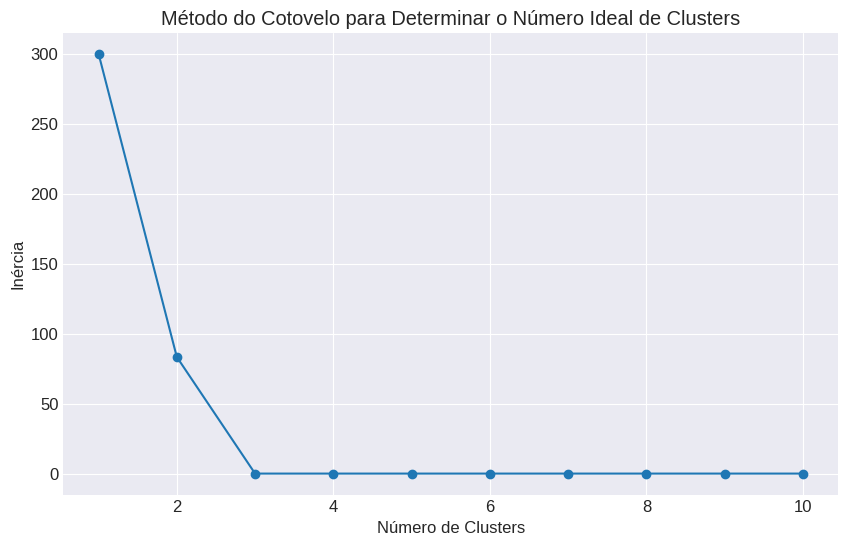

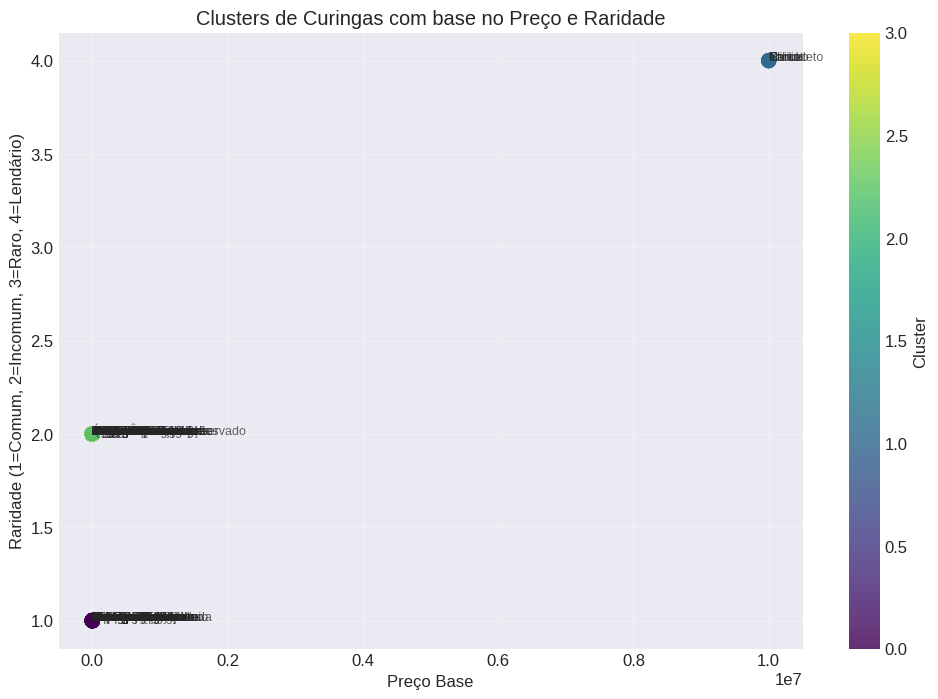


Estatísticas por cluster:

Cluster 0 (60 curingas):
Preço Base Médio: 4.07
Distribuição de Raridade:
Raridade
Comum    60
Name: count, dtype: int64
Nomes dos Curingas neste cluster:
Joker, Coringa ganancioso, Coringa Lusty, Coringa Colérico, Coringa Glutão, Coringa alegre, Coringa maluco, Coringa Maluco, Coringa Maluco, Coringa engraçado, Coringa Astuto, Coringa Astuto, Coringa Inteligente, Coringa tortuoso, Coringa Astuto, Meio Coringa, Cartões de Crédito, Bandeira, Cimeira Mística, bola 8, Impressão errada, Punho levantado, Caos, o Palhaço, Cara assustadora, Coringa abstrato, Gratificação atrasada, Gros michel, Até Steven, Estranho Todd, Estudioso, Cartão de visita, Supernova, Ride the Bus, ovo, Corredor, Ice Cream, Respingo, Coringa Azul, Coringa sem rosto, Coringa Verde, Sobreposição, Lista De Afazeres, Tabaco em tabletes, Cartão vermelho, Coringa Quadrado, Ralé, Fotografia, Desconto por correio, Alucinação, Vidente, Malabarista, Bêbado, Coringa Dourado, Pipoca, Walkie Talkie, smi

In [53]:
analise_clustering(df)

In [47]:
print("\n=== CONCLUSÕES GERAIS ===")
print("1. Identificamos se existe relação significativa entre raridade e preço base dos curingas")
print("2. Analisamos se os requisitos de desbloqueio influenciam o preço base")
print("3. Testamos se a distribuição de curingas entre as raridades é uniforme")
print("4. Agrupamos os curingas em clusters com base em suas características")

print("\nEsta análise pode ajudar jogadores a entender melhor os padrões de curingas no Balatro,")
print("auxiliando na tomada de decisões estratégicas durante uma partida.")


=== CONCLUSÕES GERAIS ===
1. Identificamos se existe relação significativa entre raridade e preço base dos curingas
2. Analisamos se os requisitos de desbloqueio influenciam o preço base
3. Testamos se a distribuição de curingas entre as raridades é uniforme
4. Agrupamos os curingas em clusters com base em suas características

Esta análise pode ajudar jogadores a entender melhor os padrões de curingas no Balatro,
auxiliando na tomada de decisões estratégicas durante uma partida.
